<a href="https://colab.research.google.com/github/PogchampMuffin3/heart-disease-classification/blob/main/heart_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
# IMPORTS
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from tensorflow import keras
from typing import List
from sklearn.neighbors import KNeighborsClassifier as KNC
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.inspection import permutation_importance

In [117]:
# CONSTANTS
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
GRIDSEARCH_SCORING = 'recall'

In [118]:
columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
df = pd.read_csv(URL, names=columns)
df['target'] = (df['target'] > 0).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [119]:
missing_values = len(df[(df == '?').any(axis=1)])
print(f'Missing values (?): {missing_values} [{missing_values/len(df):.2%}%]')
for c in columns:
  missing = len(df[df[c]=='?'])
  if missing:
    print(f'\t{c}: {missing} [{missing/len(df):.2%}%]')

df.replace('?', np.nan, inplace=True)
print("Nans after replaceing '?'")
display(df.isna().sum())
df = df.astype(float)
df = df.dropna()  # ~2% missing

Missing values (?): 6 [1.98%%]
	ca: 4 [1.32%%]
	thal: 2 [0.66%%]
Nans after replaceing '?'


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


,count
target,
0.0,160
1.0,137


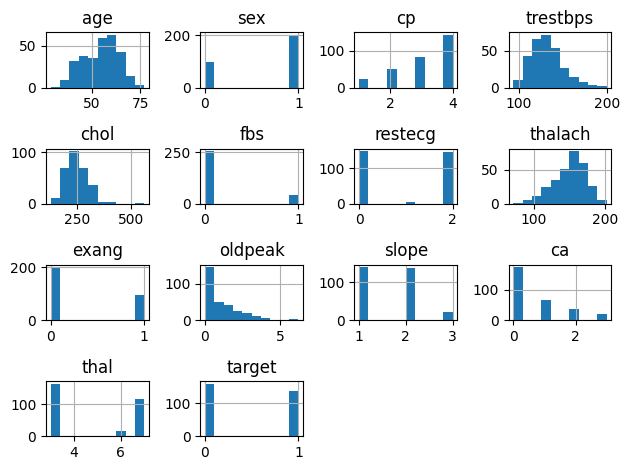

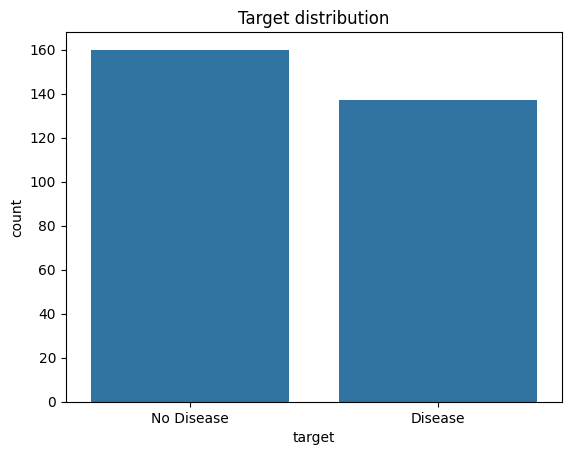

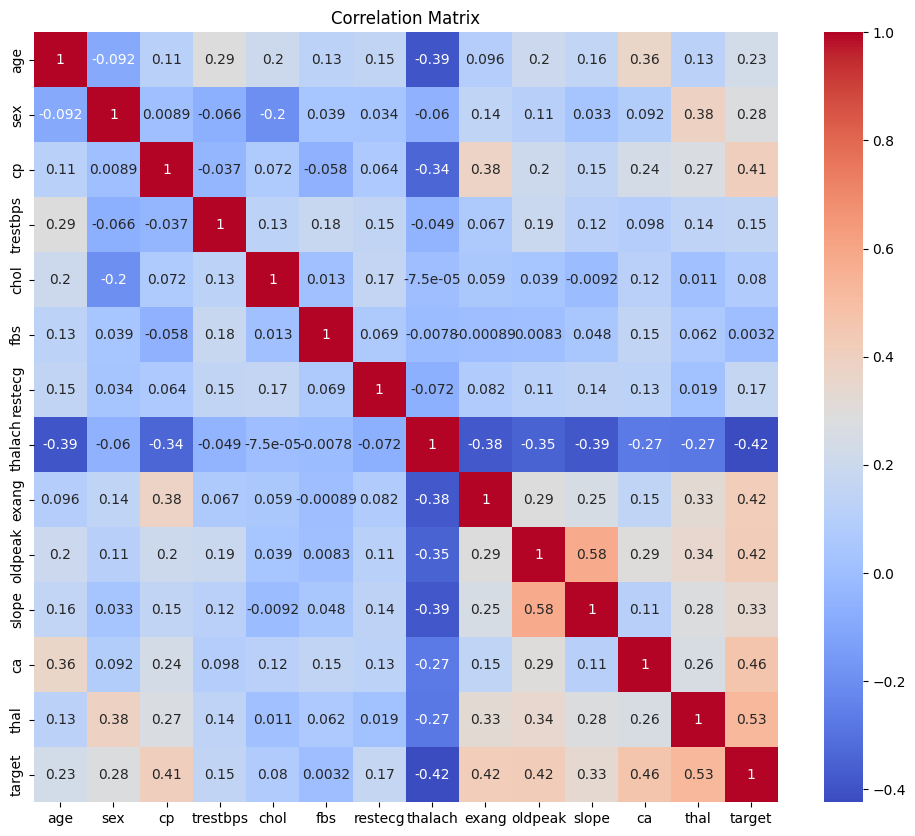

In [120]:
display(df.describe())

display(df['target'].value_counts())

df.hist()
plt.tight_layout()
plt.show()

sns.countplot(x='target', data=df)
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Target distribution')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

results_a = {}
results_r = {}
results_p = {}

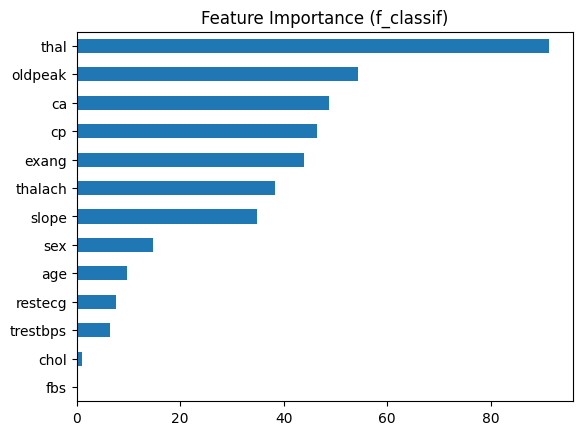

thal        91.310570
oldpeak     54.408624
ca          48.801381
cp          46.380332
exang       43.875867
thalach     38.273305
slope       34.818761
sex         14.679698
age          9.687386
restecg      7.652211
trestbps     6.427699
chol         1.032233
fbs          0.043718
dtype: float64


In [121]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X.columns)
scores.sort_values().plot(kind='barh')
plt.title('Feature Importance (f_classif)')
plt.show()
print(scores.sort_values(ascending=False))

# Max correlation = 0.58, no need for changes

In [122]:
def model_summary(y_test, y_pred, title):
  cm = confusion_matrix(y_test, y_pred)
  acc = accuracy_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)

  print(f"Accuracy:  {acc:.4f}")
  print(f"Recall:    {rec:.4f}")
  print(f"Precision: {prec:.4f}")

  print('\n',classification_report(y_test, y_pred))
  sns.heatmap(cm, annot=True)
  plt.title(f'Confusion Matrix - {title}')
  plt.show()
  return acc, rec, prec

Accuracy:  0.8667
Recall:    0.8571
Precision: 0.8571

               precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        32
         1.0       0.86      0.86      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



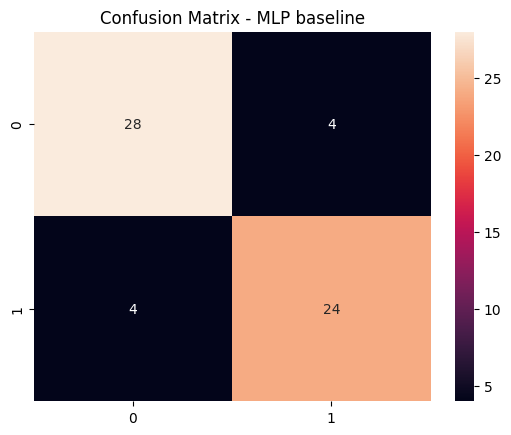

In [123]:
# MLP
mlp_baseline = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline.fit(X_train, y_train)

y_pred_MLP_baseline = mlp_baseline.predict(X_test)
results_a['MLP baseline'], results_r['MLP baseline'], results_p['MLP baseline'] = model_summary(y_test, y_pred_MLP_baseline, "MLP baseline")

Najlepsze parametry: {'activation': 'logistic', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}
Accuracy (walidacja): 0.7965
Accuracy (test): 0.8214
Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



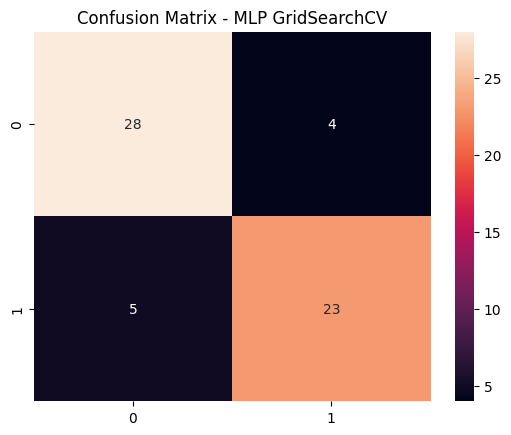

In [124]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (50, 50), (100, 50), (100, 100)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.00001, 0.0001, 0.001],
}

mlp_grid = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid = GridSearchCV(mlp_grid, param_grid_mlp, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {mlp_grid.best_params_}')
print(f'Accuracy (walidacja): {mlp_grid.best_score_:.4f}')
print(f'Accuracy (test): {mlp_grid.score(X_test, y_test):.4f}')

y_pred_MLP = mlp_grid.predict(X_test)
results_a['MLP GridSearchCV'], results_r['MLP GridSearchCV'], results_p['MLP GridSearchCV'] = model_summary(y_test, y_pred_MLP, "MLP GridSearchCV")

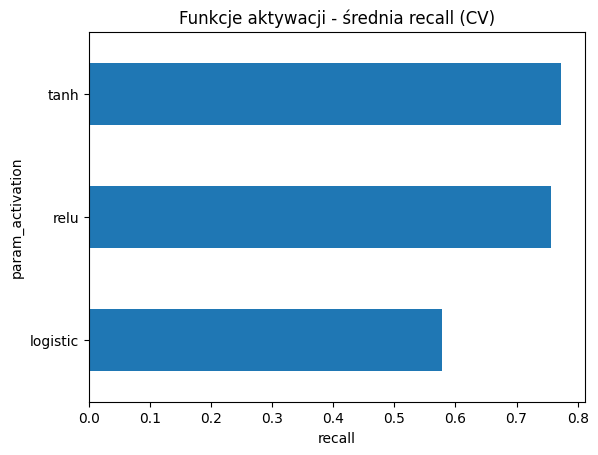

param_activation
tanh        0.772799
relu        0.756566
logistic    0.578752
Name: mean_test_score, dtype: float64


In [125]:
cv_results = pd.DataFrame(mlp_grid.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
activation_results.sort_values().plot(kind='barh', title=f'Funkcje aktywacji - średnia {GRIDSEARCH_SCORING} (CV)')
plt.xlabel(GRIDSEARCH_SCORING)
plt.show()
print(activation_results.sort_values(ascending=False))

In [126]:
# MLP (tensorflow)
tf.config.experimental.enable_op_determinism()
tf.keras.utils.set_random_seed(RANDOM_STATE)
def train_model(hidden_layers:List[int], activation, optymizer, dropout, epochs):
  model = keras.Sequential()
  for i in hidden_layers:
    model.add(keras.layers.Dense(i, activation=activation))
    model.add(keras.layers.Dropout(dropout))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer=optymizer, loss='binary_crossentropy', metrics=[GRIDSEARCH_SCORING])
  early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
  model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stop])
  return model

Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[50] 0.8571
[100] 0.8214
[200] 0.7857
[50, 50] 0.7500
[100, 50] 0.8214
[100, 100] 0.8571
[200, 100] 0.7857
[100, 50, 25] 0.7857
[25, 50, 100] 0.7500
[100, 50, 100] 0.8214
Best: {'layers': [50], 'rec': 0.8571428656578064} 

Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



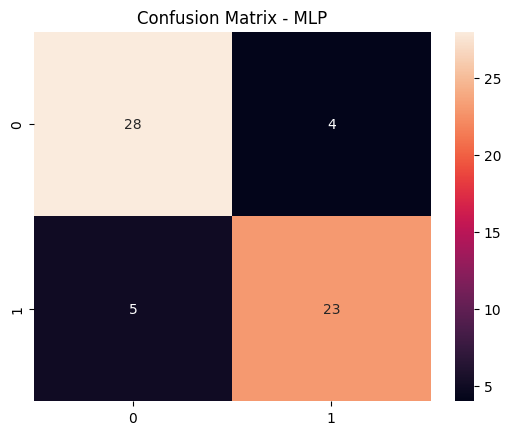

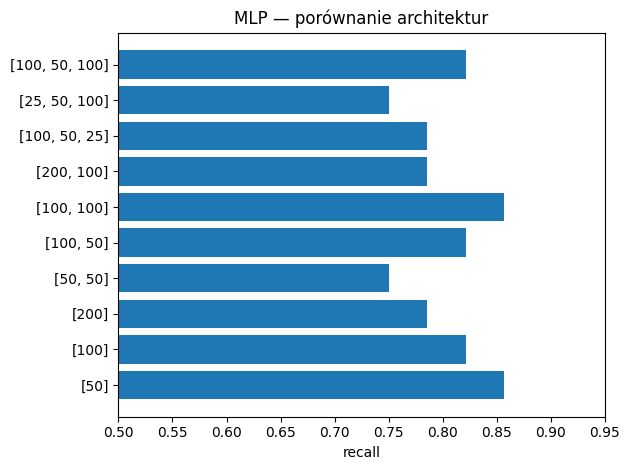

In [127]:
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
architectures = [
    [50],
    [100],
    [200],
    [50,50],
    [100,50],
    [100,100],
    [200,100],
    [100,50,25],
    [25,50,100],
    [100,50,100]
]
arch_accs = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test, y_test, verbose=0, return_dict=True)[GRIDSEARCH_SCORING]
  arch_accs.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

model = train_model(best['layers'], 'relu', 'adam', 0.2, 200)
y_pred_TF_proba = model.predict(X_test, verbose=0)
y_pred_TF = (y_pred_TF_proba > 0.4).astype(int)
results_a['TensorFlow MLP'], results_r['TensorFlow MLP'], results_p['TensorFlow MLP'] = model_summary(y_test, y_pred_TF, "MLP")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_accs)
plt.xlabel(GRIDSEARCH_SCORING)
plt.title('MLP — porównanie architektur')
plt.xlim(0.5, 0.95)
plt.tight_layout()
plt.show()

Accuracy:  0.8500
Recall:    0.7857
Precision: 0.8800

               precision    recall  f1-score   support

         0.0       0.83      0.91      0.87        32
         1.0       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



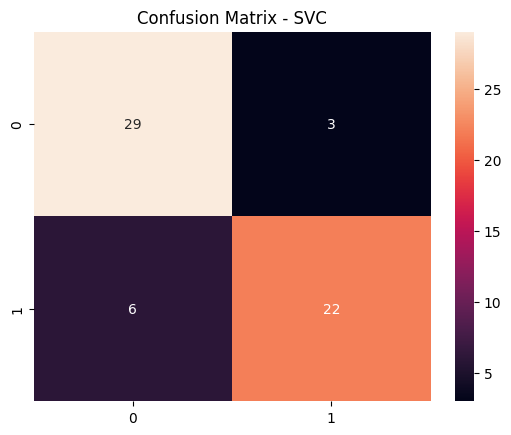

In [128]:
# SVC
svc_baseline = SVC(random_state=RANDOM_STATE)
svc_baseline.fit(X_train, y_train)

y_pred_SVC_baseline = svc_baseline.predict(X_test)
results_a['SVC baseline'], results_r['SVC baseline'], results_p['SVC baseline'] = model_summary(y_test, y_pred_SVC_baseline, "SVC")

Najlepsze parametry: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
Accuracy (walidacja): 0.8152
Accuracy (test): 0.7857
Accuracy:  0.8167
Recall:    0.7857
Precision: 0.8148

               precision    recall  f1-score   support

         0.0       0.82      0.84      0.83        32
         1.0       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



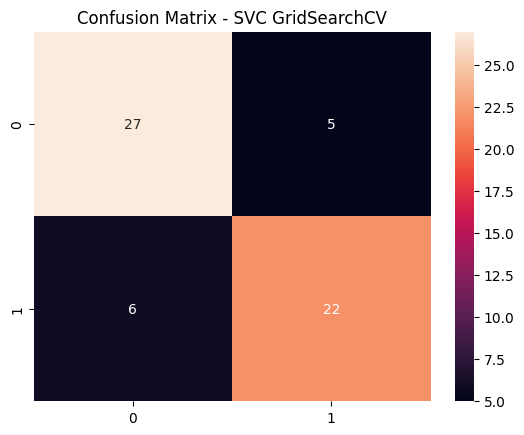

In [129]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

svc_grid = SVC(random_state=RANDOM_STATE)
svc_grid = GridSearchCV(svc_grid, param_grid_svc, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
svc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {svc_grid.best_params_}')
print(f'Accuracy (walidacja): {svc_grid.best_score_:.4f}')
print(f'Accuracy (test): {svc_grid.score(X_test, y_test):.4f}')

y_pred_SVC = svc_grid.predict(X_test)
results_a['SVC GridSearchCV'], results_r['SVC GridSearchCV'], results_p['SVC GridSearchCV'] = model_summary(y_test, y_pred_SVC, "SVC GridSearchCV")

In [130]:
# SVC kernel comparison
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train, y_train)
    print(f'{kernel:10s} {svc.score(X_test, y_test):.4f}')

linear     0.8500
rbf        0.8500
poly       0.8500
sigmoid    0.8500


Accuracy:  0.8833
Recall:    0.8214
Precision: 0.9200

               precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        32
         1.0       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



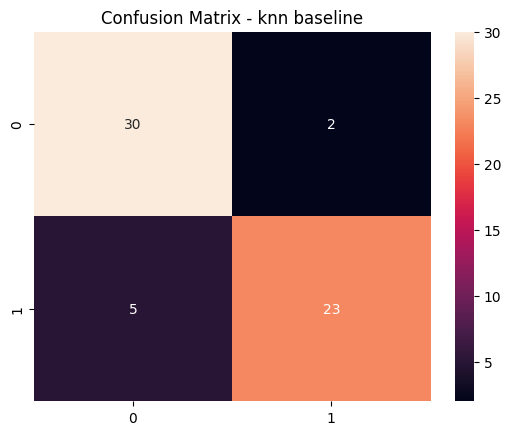

In [131]:
#KNeighborsClassifier
knn_base=KNC()
knn_base.fit(X_train,y_train)

y_pred_knn_base = knn_base.predict(X_test)
results_a['knn baseline'], results_r['knn baseline'], results_p['knn baseline'] = model_summary(y_test, y_pred_knn_base, "knn baseline")

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Accuracy (walidacja): 0.7874
Accuracy (test): 0.7857
Accuracy:  0.8667
Recall:    0.7857
Precision: 0.9167

               precision    recall  f1-score   support

         0.0       0.83      0.94      0.88        32
         1.0       0.92      0.79      0.85        28

    accuracy                           0.87        60
   macro avg       0.88      0.86      0.86        60
weighted avg       0.87      0.87      0.87        60



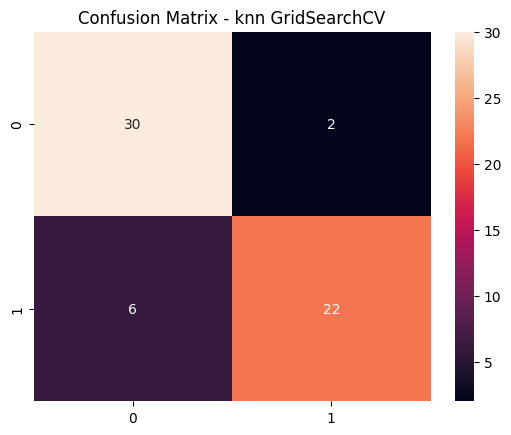

In [132]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = KNC()
knn_grid = GridSearchCV(knn_grid, param_grid_knn, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {knn_grid.best_params_}')
print(f'Accuracy (walidacja): {knn_grid.best_score_:.4f}')
print(f'Accuracy (test): {knn_grid.score(X_test, y_test):.4f}')

y_pred_knn = knn_grid.predict(X_test)
results_a['knn GridSearchCV'], results_r['knn GridSearchCV'], results_p['knn GridSearchCV'] = model_summary(y_test, y_pred_knn, "knn GridSearchCV")

Accuracy:  0.8667
Recall:    0.8214
Precision: 0.8846

               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88        32
         1.0       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



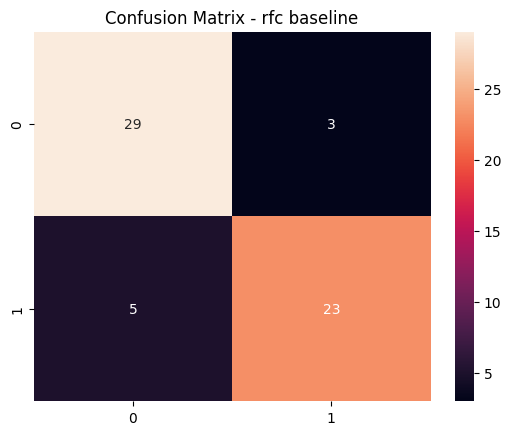

In [133]:
#RandomForestClassifier
rfc_base = RFC(random_state=RANDOM_STATE)
rfc_base.fit(X_train, y_train)

y_pred_rfc_base = rfc_base.predict(X_test)
results_a['rfc baseline'], results_r['rfc baseline'], results_p['rfc baseline'] = model_summary(y_test, y_pred_rfc_base, "rfc baseline")

Najlepsze parametry: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy (walidacja): 0.8061
Accuracy (test): 0.7500
Accuracy:  0.8333
Recall:    0.7500
Precision: 0.8750

               precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



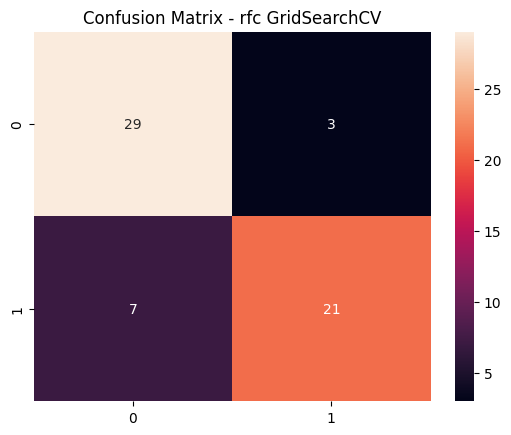

In [134]:
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = RFC(random_state=RANDOM_STATE)
rfc_grid = GridSearchCV(rfc_grid, param_grid_rfc, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {rfc_grid.best_params_}')
print(f'Accuracy (walidacja): {rfc_grid.best_score_:.4f}')
print(f'Accuracy (test): {rfc_grid.score(X_test, y_test):.4f}')

y_pred_rfc = rfc_grid.predict(X_test)
results_a['rfc GridSearchCV'], results_r['rfc GridSearchCV'], results_p['rfc GridSearchCV'] = model_summary(y_test, y_pred_rfc, "rfc GridSearchCV")

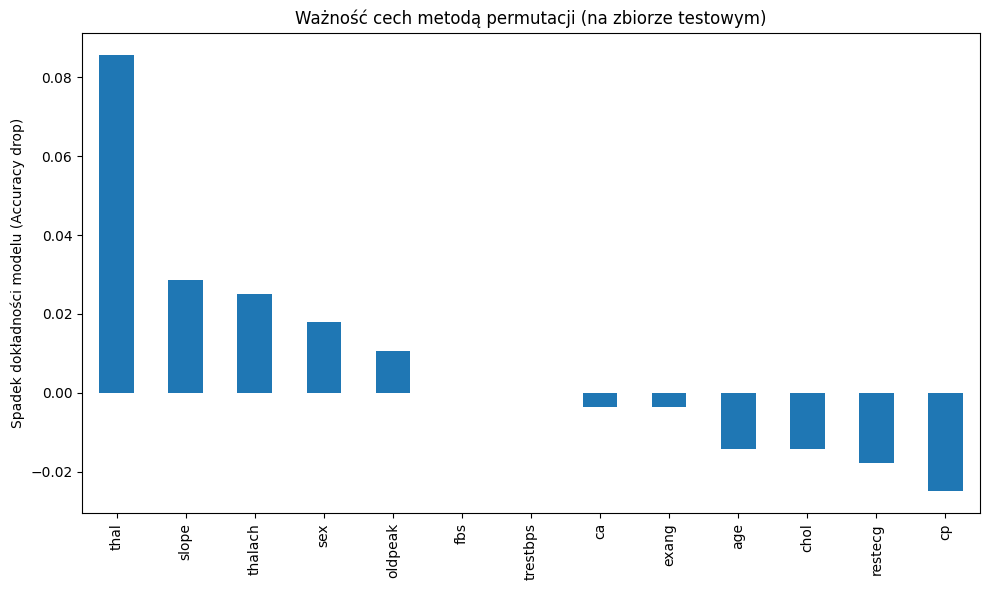

In [135]:
result = permutation_importance(
    rfc_grid, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(result.importances_mean, index=columns[0:13]).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_importances.plot(kind='bar')
plt.title("Ważność cech metodą permutacji (na zbiorze testowym)")
plt.ylabel("Spadek dokładności modelu (Accuracy drop)")
plt.tight_layout()
plt.show()

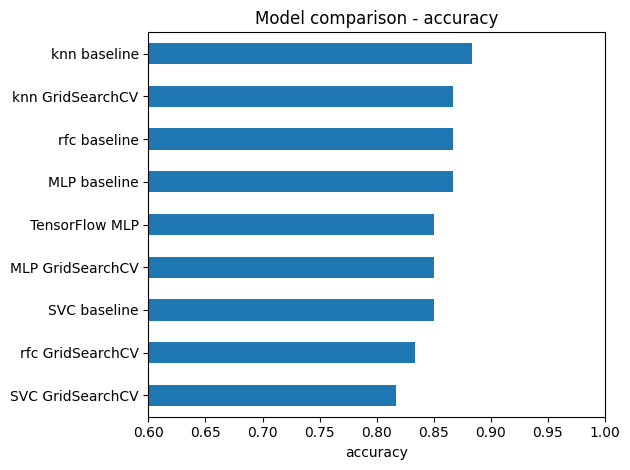

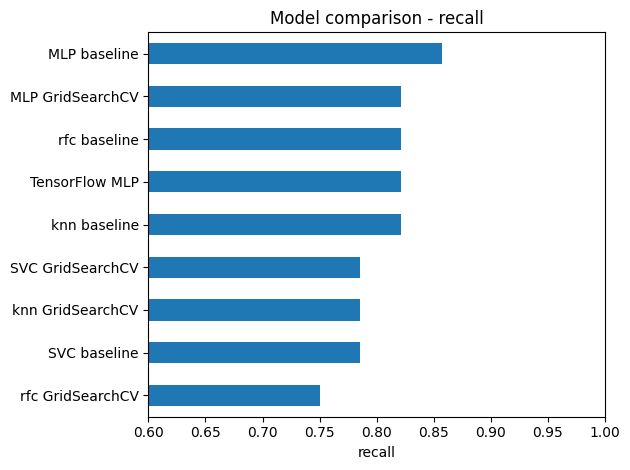

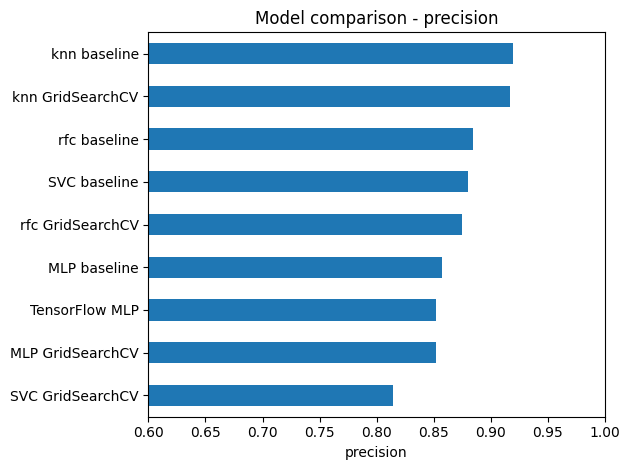

In [136]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()

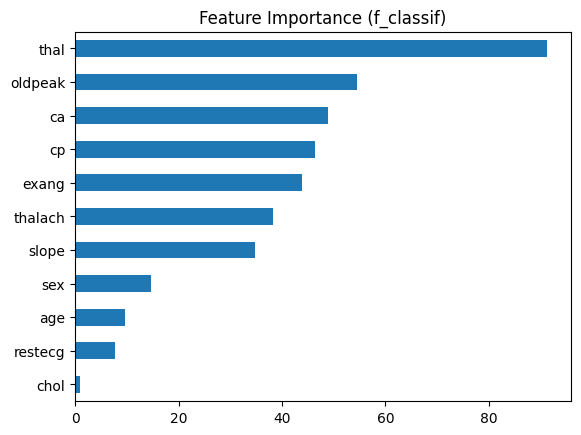

thal       91.310570
oldpeak    54.408624
ca         48.801381
cp         46.380332
exang      43.875867
thalach    38.273305
slope      34.818761
sex        14.679698
age         9.687386
restecg     7.652211
chol        1.032233
dtype: float64


In [140]:
#Usuwanie niepotrzebnych cech
# ,'restecg','slope','sex','age','oldpeak','thalach','exang'
X = df.drop(['target','fbs','trestbps'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

selector = SelectKBest(f_classif, k='all')
selector.fit(X_train, y_train)

scores = pd.Series(selector.scores_, index=X.columns)
scores.sort_values().plot(kind='barh')
plt.title('Feature Importance (f_classif)')
plt.show()
print(scores.sort_values(ascending=False))

Accuracy:  0.8333
Recall:    0.7857
Precision: 0.8462

               precision    recall  f1-score   support

         0.0       0.82      0.88      0.85        32
         1.0       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60



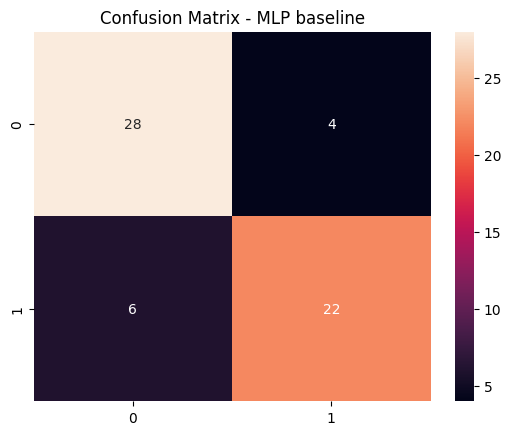

In [141]:
# MLP
mlp_baseline = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_baseline.fit(X_train, y_train)

y_pred_MLP_baseline = mlp_baseline.predict(X_test)
results_a['MLP baseline'], results_r['MLP baseline'], results_p['MLP baseline'] = model_summary(y_test, y_pred_MLP_baseline, "MLP baseline")

Najlepsze parametry: {'activation': 'tanh', 'alpha': 1e-05, 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}
Accuracy (walidacja): 0.8333
Accuracy (test): 0.7143
Accuracy:  0.8500
Recall:    0.7143
Precision: 0.9524

               precision    recall  f1-score   support

         0.0       0.79      0.97      0.87        32
         1.0       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



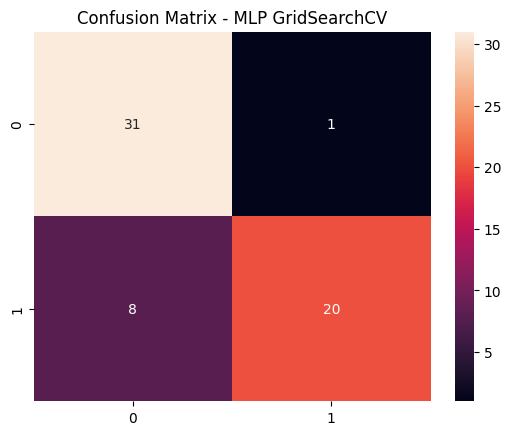

In [142]:
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (200,), (50, 50), (100, 50), (100, 100)],
    'activation': ['logistic', 'tanh', 'relu'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.00001, 0.0001, 0.001],
}

mlp_grid = MLPClassifier(random_state=RANDOM_STATE, max_iter=2000)
mlp_grid = GridSearchCV(mlp_grid, param_grid_mlp, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
mlp_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {mlp_grid.best_params_}')
print(f'Accuracy (walidacja): {mlp_grid.best_score_:.4f}')
print(f'Accuracy (test): {mlp_grid.score(X_test, y_test):.4f}')

y_pred_MLP = mlp_grid.predict(X_test)
results_a['MLP GridSearchCV'], results_r['MLP GridSearchCV'], results_p['MLP GridSearchCV'] = model_summary(y_test, y_pred_MLP, "MLP GridSearchCV")

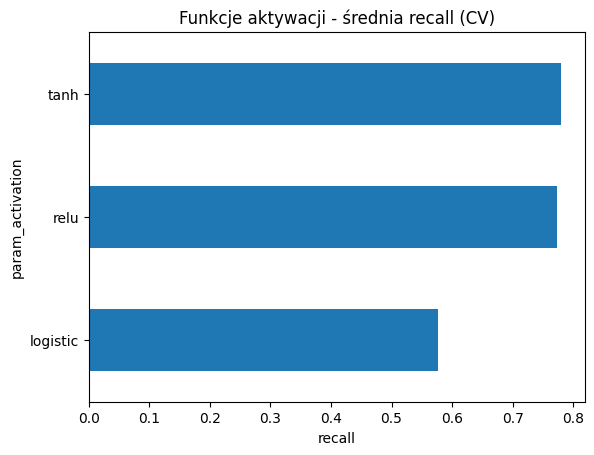

param_activation
tanh        0.779798
relu        0.772763
logistic    0.576587
Name: mean_test_score, dtype: float64


In [143]:
cv_results = pd.DataFrame(mlp_grid.cv_results_)
activation_results = cv_results.groupby('param_activation')['mean_test_score'].mean()
activation_results.sort_values().plot(kind='barh', title=f'Funkcje aktywacji - średnia {GRIDSEARCH_SCORING} (CV)')
plt.xlabel(GRIDSEARCH_SCORING)
plt.show()
print(activation_results.sort_values(ascending=False))

In [144]:
# MLP (tensorflow)
tf.config.experimental.enable_op_determinism()
tf.keras.utils.set_random_seed(RANDOM_STATE)
def train_model(hidden_layers:List[int], activation, optymizer, dropout, epochs):
  model = keras.Sequential()
  for i in hidden_layers:
    model.add(keras.layers.Dense(i, activation=activation))
    model.add(keras.layers.Dropout(dropout))
  model.add(keras.layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer=optymizer, loss='binary_crossentropy', metrics=[GRIDSEARCH_SCORING])
  early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
  model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, verbose=0, callbacks=[early_stop])
  return model

Dostępne GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[50] 0.7857
[100] 0.8571
[200] 0.8214
[50, 50] 0.8571
[100, 50] 0.7143
[100, 100] 0.8571
[200, 100] 0.7857
[100, 50, 25] 0.7857
[25, 50, 100] 0.8214
[100, 50, 100] 0.7857
Best: {'layers': [100], 'rec': 0.8571428656578064} 

Accuracy:  0.8500
Recall:    0.8214
Precision: 0.8519

               precision    recall  f1-score   support

         0.0       0.85      0.88      0.86        32
         1.0       0.85      0.82      0.84        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60



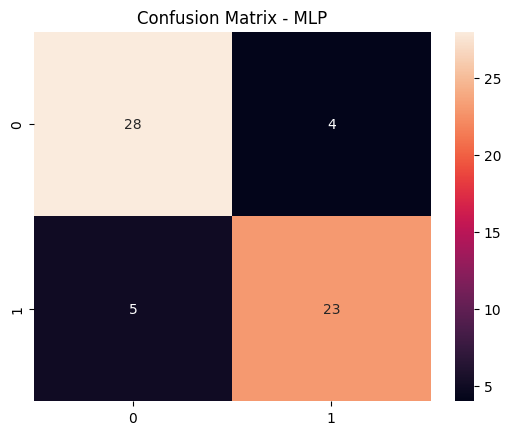

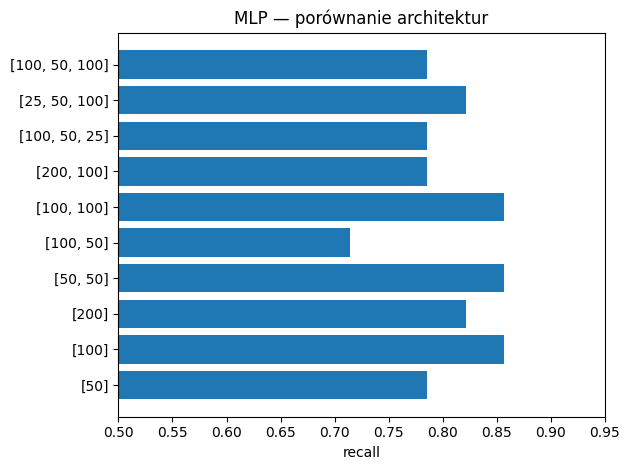

In [145]:
print("Dostępne GPU:", tf.config.list_physical_devices('GPU'))
architectures = [
    [50],
    [100],
    [200],
    [50,50],
    [100,50],
    [100,100],
    [200,100],
    [100,50,25],
    [25,50,100],
    [100,50,100]
]
arch_accs = []
best = {'rec': 0}

for layers in architectures:
  m = train_model(layers, 'relu', 'adam', 0.2, 200)
  rec = m.evaluate(X_test, y_test, verbose=0, return_dict=True)[GRIDSEARCH_SCORING]
  arch_accs.append(rec)
  if best['rec'] < rec:
    best = {'layers': layers, 'rec': rec}
  print(f'{layers} {rec:.4f}')
print('Best:', best, '\n')

model = train_model(best['layers'], 'relu', 'adam', 0.2, 200)
y_pred_TF_proba = model.predict(X_test, verbose=0)
y_pred_TF = (y_pred_TF_proba > 0.4).astype(int)
results_a['TensorFlow MLP'], results_r['TensorFlow MLP'], results_p['TensorFlow MLP'] = model_summary(y_test, y_pred_TF, "MLP")

arch_labels = [str(a) for a in architectures]
plt.barh(arch_labels, arch_accs)
plt.xlabel(GRIDSEARCH_SCORING)
plt.title('MLP — porównanie architektur')
plt.xlim(0.5, 0.95)
plt.tight_layout()
plt.show()

Accuracy:  0.8500
Recall:    0.7143
Precision: 0.9524

               precision    recall  f1-score   support

         0.0       0.79      0.97      0.87        32
         1.0       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



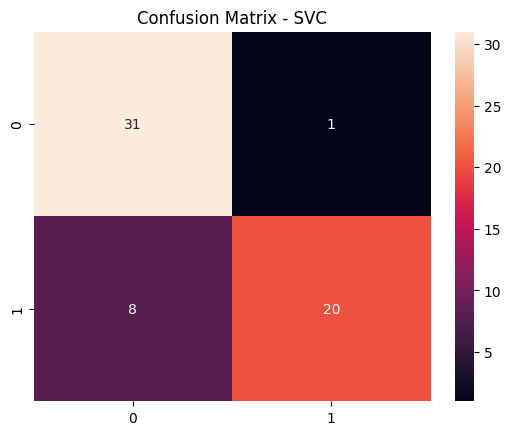

In [146]:
# SVC
svc_baseline = SVC(random_state=RANDOM_STATE)
svc_baseline.fit(X_train, y_train)

y_pred_SVC_baseline = svc_baseline.predict(X_test)
results_a['SVC baseline'], results_r['SVC baseline'], results_p['SVC baseline'] = model_summary(y_test, y_pred_SVC_baseline, "SVC")

Najlepsze parametry: {'C': 100, 'gamma': 'scale', 'kernel': 'sigmoid'}
Accuracy (walidacja): 0.7883
Accuracy (test): 0.7143
Accuracy:  0.8000
Recall:    0.7143
Precision: 0.8333

               precision    recall  f1-score   support

         0.0       0.78      0.88      0.82        32
         1.0       0.83      0.71      0.77        28

    accuracy                           0.80        60
   macro avg       0.81      0.79      0.80        60
weighted avg       0.80      0.80      0.80        60



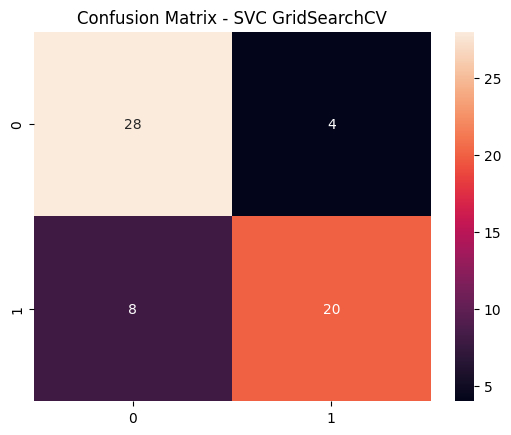

In [147]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.1, 1, 10]
}

svc_grid = SVC(random_state=RANDOM_STATE)
svc_grid = GridSearchCV(svc_grid, param_grid_svc, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
svc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {svc_grid.best_params_}')
print(f'Accuracy (walidacja): {svc_grid.best_score_:.4f}')
print(f'Accuracy (test): {svc_grid.score(X_test, y_test):.4f}')

y_pred_SVC = svc_grid.predict(X_test)
results_a['SVC GridSearchCV'], results_r['SVC GridSearchCV'], results_p['SVC GridSearchCV'] = model_summary(y_test, y_pred_SVC, "SVC GridSearchCV")

In [148]:
# SVC kernel comparison
for kernel in ['linear', 'rbf', 'poly', 'sigmoid']:
    svc = SVC(kernel=kernel, random_state=RANDOM_STATE)
    svc.fit(X_train, y_train)
    print(f'{kernel:10s} {svc.score(X_test, y_test):.4f}')

linear     0.8667
rbf        0.8500
poly       0.8667
sigmoid    0.8833


Accuracy:  0.8833
Recall:    0.8214
Precision: 0.9200

               precision    recall  f1-score   support

         0.0       0.86      0.94      0.90        32
         1.0       0.92      0.82      0.87        28

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



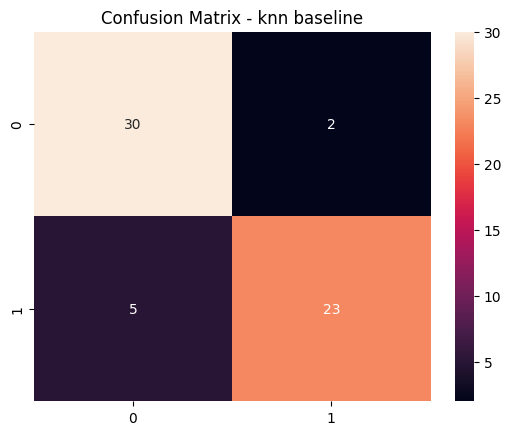

In [149]:
#KNeighborsClassifier
knn_base=KNC()
knn_base.fit(X_train,y_train)

y_pred_knn_base = knn_base.predict(X_test)
results_a['knn baseline'], results_r['knn baseline'], results_p['knn baseline'] = model_summary(y_test, y_pred_knn_base, "knn baseline")

Najlepsze parametry: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Accuracy (walidacja): 0.8429
Accuracy (test): 0.7143
Accuracy:  0.8333
Recall:    0.7143
Precision: 0.9091

               precision    recall  f1-score   support

         0.0       0.79      0.94      0.86        32
         1.0       0.91      0.71      0.80        28

    accuracy                           0.83        60
   macro avg       0.85      0.83      0.83        60
weighted avg       0.85      0.83      0.83        60



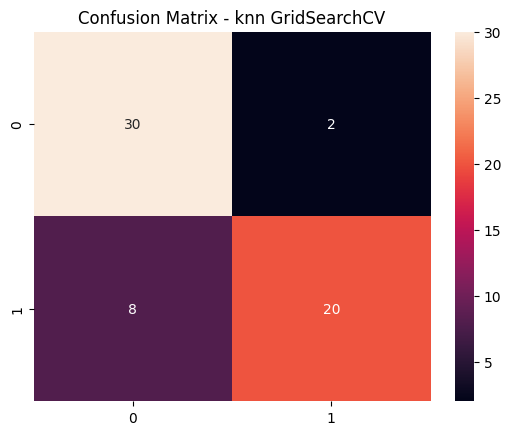

In [150]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid = KNC()
knn_grid = GridSearchCV(knn_grid, param_grid_knn, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {knn_grid.best_params_}')
print(f'Accuracy (walidacja): {knn_grid.best_score_:.4f}')
print(f'Accuracy (test): {knn_grid.score(X_test, y_test):.4f}')

y_pred_knn = knn_grid.predict(X_test)
results_a['knn GridSearchCV'], results_r['knn GridSearchCV'], results_p['knn GridSearchCV'] = model_summary(y_test, y_pred_knn, "knn GridSearchCV")

Accuracy:  0.8333
Recall:    0.7500
Precision: 0.8750

               precision    recall  f1-score   support

         0.0       0.81      0.91      0.85        32
         1.0       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



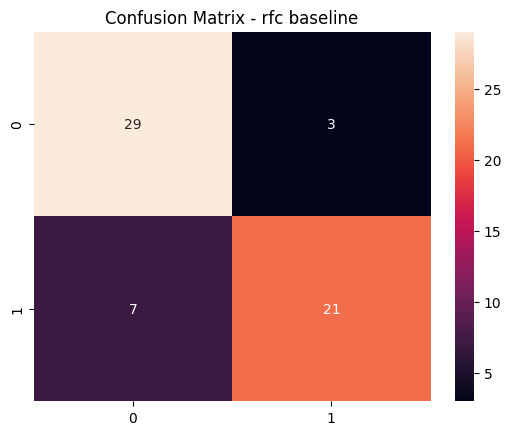

In [151]:
#RandomForestClassifier
rfc_base = RFC(random_state=RANDOM_STATE)
rfc_base.fit(X_train, y_train)

y_pred_rfc_base = rfc_base.predict(X_test)
results_a['rfc baseline'], results_r['rfc baseline'], results_p['rfc baseline'] = model_summary(y_test, y_pred_rfc_base, "rfc baseline")

Najlepsze parametry: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Accuracy (walidacja): 0.7970
Accuracy (test): 0.7143
Accuracy:  0.8167
Recall:    0.7143
Precision: 0.8696

               precision    recall  f1-score   support

         0.0       0.78      0.91      0.84        32
         1.0       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



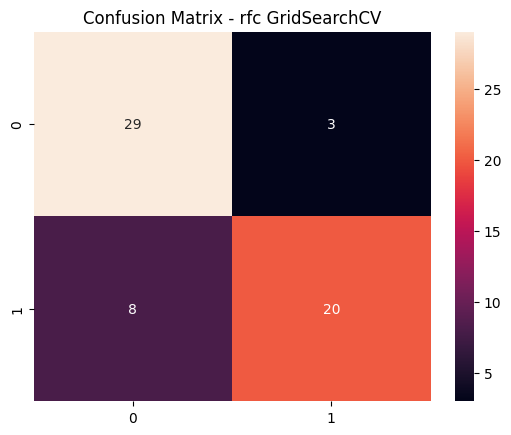

In [152]:
param_grid_rfc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rfc_grid = RFC(random_state=RANDOM_STATE)
rfc_grid = GridSearchCV(rfc_grid, param_grid_rfc, cv=CV_FOLDS, scoring=GRIDSEARCH_SCORING, n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print(f'Najlepsze parametry: {rfc_grid.best_params_}')
print(f'Accuracy (walidacja): {rfc_grid.best_score_:.4f}')
print(f'Accuracy (test): {rfc_grid.score(X_test, y_test):.4f}')

y_pred_rfc = rfc_grid.predict(X_test)
results_a['rfc GridSearchCV'], results_r['rfc GridSearchCV'], results_p['rfc GridSearchCV'] = model_summary(y_test, y_pred_rfc, "rfc GridSearchCV")

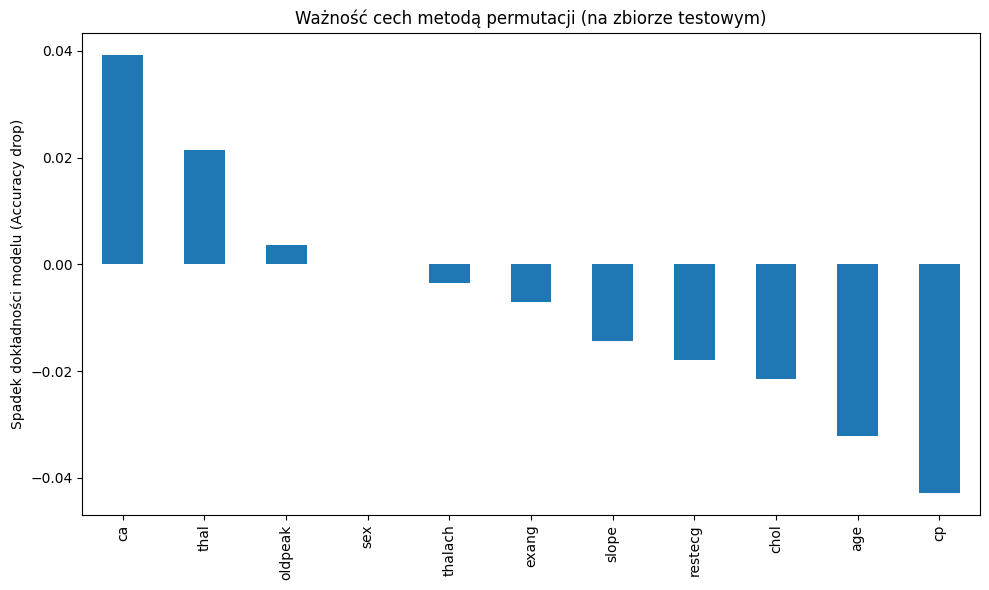

In [153]:
result = permutation_importance(
    rfc_grid, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_importances.plot(kind='bar')
plt.title("Ważność cech metodą permutacji (na zbiorze testowym)")
plt.ylabel("Spadek dokładności modelu (Accuracy drop)")
plt.tight_layout()
plt.show()

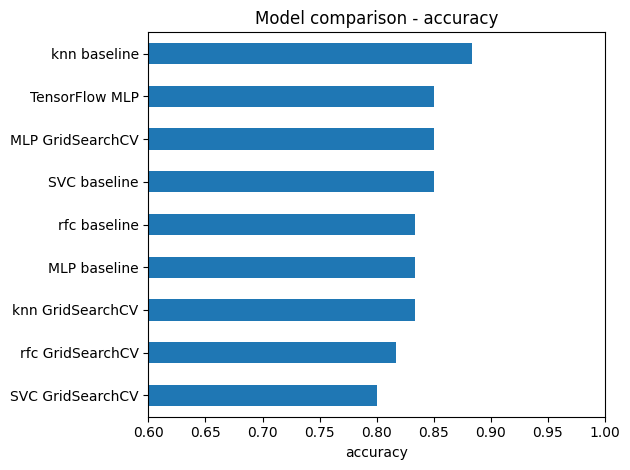

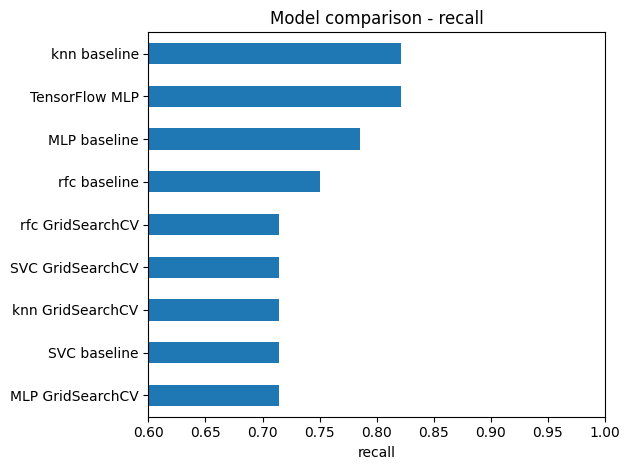

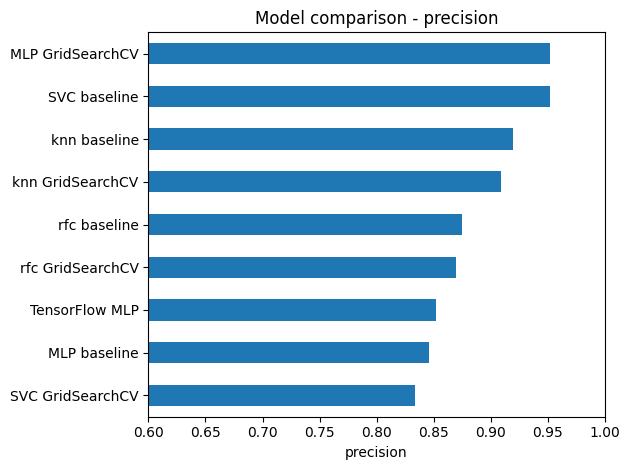

In [154]:
for name, r in {'accuracy': results_a, 'recall': results_r, 'precision': results_p}.items():
  pd.Series(r).sort_values().plot(kind='barh', title=f'Model comparison - {name}')
  plt.xlabel(name)
  plt.xlim(0.6, 1.0)
  plt.tight_layout()
  plt.show()